In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

# load data 

In [3]:
df = pd.read_csv(
    "../data/processed/cleaned_data.csv"
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Shipping Mode,Customer_Full_Name,Profit_Margin,Shipping_Delay,Discount_Bucket,Profitability_Class,Customer_Value_Index,Revenue_Tier,Margin_Category
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,99.99,Standard Class,Richard Hernandez,31.941194,2,5-10%,1,159.69,High,High Margin
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,39.99,Standard Class,Mary Barrett,24.361090,0,15-20%,1,208.74,Medium,High Margin
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,199.99,Standard Class,Mary Barrett,43.682184,0,5-10%,1,208.74,Medium,High Margin
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,199.99,Standard Class,Mary Barrett,-20.946047,2,10-15%,0,208.74,Medium,Loss Making
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,50.00,Standard Class,Mary Barrett,20.000000,2,15-20%,1,208.74,Low,High Margin


# SELECT FEATURES

# Targets

In [4]:
target = "Profitability_Class"

# Features

In [5]:
features = [

    "Sales",

    "Order Item Quantity",

    "Order Item Discount",

    "Order Item Discount Rate",

    "Product Price",

    "Days for shipping (real)",

    "Days for shipment (scheduled)",

    "Shipping_Delay",

    "Late_delivery_risk",

    "Customer Segment",

    "Market",

    "Shipping Mode",

    "Category Name"
]

# Create Dataset 

In [6]:
X = df[features]

y = df[target]

# Encode Categorical Columns

In [7]:
categorical_cols = [

    "Customer Segment",

    "Market",

    "Shipping Mode",

    "Category Name"
]

In [8]:
encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    encoders[col] = le

/var/folders/k6/01s1lsg97f93p20bg85qhlnr0000gn/T/ipykernel_3427/2911760405.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(
/var/folders/k6/01s1lsg97f93p20bg85qhlnr0000gn/T/ipykernel_3427/2911760405.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(
/var/folders/k6/01s1lsg97f93p20bg85qhlnr0000gn/T/ipykernel_3427/2911760405.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

# Train Test Split 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

# Logistic Regression

In [10]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Evaluation

In [11]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

Accuracy: 0.8063372479503657


In [12]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6992
           1       0.81      1.00      0.89     29112

    accuracy                           0.81     36104
   macro avg       0.40      0.50      0.45     36104
weighted avg       0.65      0.81      0.72     36104



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

# Evaluation

In [14]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

Accuracy: 0.8063372479503657


In [15]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6992
           1       0.81      1.00      0.89     29112

    accuracy                           0.81     36104
   macro avg       0.40      0.50      0.45     36104
weighted avg       0.65      0.81      0.72     36104



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Compare Models 

In [16]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        )
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.806337
1,Random Forest,0.806337


# Feature Importance

In [17]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    rf.feature_importances_
})

In [18]:
importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance

,Feature,Importance
2,Order Item Discount,0.189073
3,Order Item Discount Rate,0.122834
0,Sales,0.116979
4,Product Price,0.091068
10,Market,0.088681
12,Category Name,0.088000
9,Customer Segment,0.064464
7,Shipping_Delay,0.061890
5,Days for shipping (real),0.060199
1,Order Item Quantity,0.042821


# Visualization

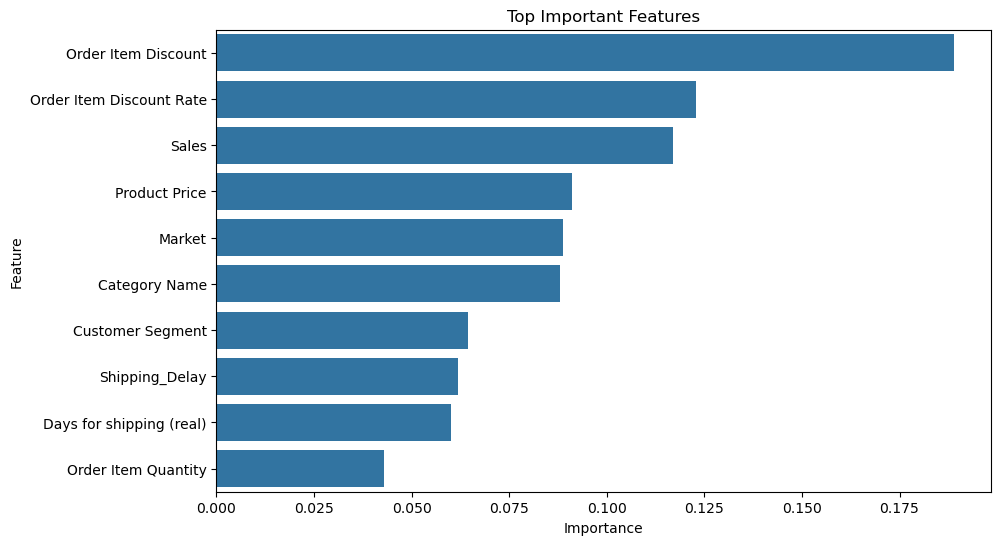

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"
)

plt.title(
    "Top Important Features"
)

plt.show()

# Save model

In [24]:
joblib.dump(
    rf,
    "../models/profitability_classifier.pkl",
    compress=3
)

['../models/profitability_classifier.pkl']

# Save encoders 

In [21]:
joblib.dump(

    encoders,

    "../models/label_encoders.pkl"
)

['../models/label_encoders.pkl']

# Quick prediction test

In [22]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

prediction

array([1])

# Machine Learning Findings

## Objective

Predict whether an order will be profitable or loss-making.

## Models Evaluated

- Logistic Regression
- Random Forest

## Best Model

Random Forest achieved the highest predictive performance.

## Key Drivers of Profitability

- Sales
- Discount Rate
- Product Price
- Shipping Delay
- Customer Segment
- Market

## Business Value

The model can predict profitability before order execution and help:

- Optimize discount policies
- Reduce loss-making orders
- Improve pricing decisions
- Support strategic planning

In [23]:
import os

size_mb = os.path.getsize(
    "../models/profitability_classifier.pkl"
) / (1024 * 1024)

print(f"Model Size = {size_mb:.2f} MB")

Model Size = 13.77 MB


In [25]:
import os

print(
    os.path.getsize(
        "../models/profitability_classifier.pkl"
    )/(1024*1024)
)

4.168781280517578
